In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import GroupKFold
import logging
import sys
from pathlib import Path

# add the directory to the path
sys.path.insert(0, str(Path.cwd()))

In [ ]:
import os
import pickle
from pathlib import Path
from typing import Iterable, Optional, Union, List, Tuple, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from Delong_test import delong_roc_variance, compute_ground_truth_statistics, fastDeLong_no_weights

def delong_test_comparison(y_true, y_pred1, y_pred2, alpha=0.05):
    """
    Compare two ROC curves using DeLong's test for statistical significance.
    
    Args:
        y_true: True binary labels
        y_pred1: Predictions from first model (
        y_pred2: Predictions from second model 
        alpha: Significance level (default 0.05)
    
    Returns:
        p-value
    """
    # Compute AUC and variance for each model
    auc1, var1 = delong_roc_variance(y_true, y_pred1)
    auc2, var2 = delong_roc_variance(y_true, y_pred2)
    
    # Compute covariance between the two AUCs
    # For this we need to combine predictions and compute joint variance
    predictions_combined = np.array([y_pred1, y_pred2])
    order, label_1_count = compute_ground_truth_statistics(y_true)
    predictions_sorted_transposed = predictions_combined[:, order]
    aucs, cov_matrix = fastDeLong_no_weights(predictions_sorted_transposed, label_1_count)
    
    # Extract covariance
    cov_12 = cov_matrix[0, 1] if cov_matrix.ndim > 1 else 0
    
    # Compute test statistic
    auc_diff = auc1 - auc2
    var_diff = var1 + var2 - 2 * cov_12
    
    if var_diff <= 0:
        var_diff = 1e-10  # Avoid division by zero
    
    z_score = auc_diff / np.sqrt(var_diff)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # Two-tailed test
    

    return p_value

def p_to_stars(p: float) -> str:
    """Converts a p-value to a significance star string."""
    if p <= 0.0001: return '****'
    if p <= 0.001: return '***'
    if p <= 0.01: return '**'
    if p <= 0.05: return '*'
    return 'ns'

def plot_auc_from_folder(
    architecture: Literal["MLEF", "DLIF"],
    outcome: str,                                              # e.g. OS_24, OS_6, DCR
    analyses: Union[str, Iterable[str]],                       # e.g. "C23" or ["C2", "ADENO", ...]
    *,
    modality_order: Optional[List[str]] = None,                # enforce x-axis order
    exclude_modalities: Iterable[str] = ("DP", "FMRAD", "PYRAD"),
    title_prefix: Optional[str] = None,
    min_bubble: float = 30,
    max_bubble: float = 250,
    show: bool = True,
    save_dir: Optional[Union[str, Path]] = None
):
    """
    Expected per-analysis layout (e.g. 'C23'):
        MLEF/ (or DLIF/)
         OS_24/ (or DCR/ OR OS_6/)
          C23/
            RWD/
              model_XX.pkl
              train_set.xlsx
              test_set.xlsx
              prediction_CV.xlsx   (columns: Subject, y_pred, y_true)
              results.xlsx      (metrics incl. CV AUC)
            RWD_DP/
               RWD_ONLY/         (MLEF only)
            RWD_PYRAD/
            RWD_FMRAD/
            RWD_DP_PYRAD/
            RWD_DP_FMRAD/
    """

    # ------------------------- utilities -------------------------
    def _parse_mean_std(val) -> Tuple[float, float]:
        if pd.isna(val):
            return (np.nan, np.nan)
        if isinstance(val, (int, float, np.floating)):
            return (float(val), 0.0)
        s = str(val).replace("+/-", "±")
        parts = [p.strip() for p in s.split("±")]
        try:
            if len(parts) == 2:
                return (float(parts[0]), float(parts[1]))
            return (float(parts[0]), 0.0)
        except Exception:
            return (np.nan, np.nan)

    def _read_auc_cv(results_path: Path) -> Tuple[float, float]:
        if results_path is None or not results_path.exists():
            return (np.nan, np.nan)
        df = pd.read_excel(results_path)
        # 1) direct 'CV AUC'
        for col in df.columns:
            if str(col).strip().upper() in ("CV AUC", "CV_AUC", "AUC_CV", "AUC_cv"):
                return _parse_mean_std(df[col].iloc[0])
        # 2) SET + AUC with a 'CV' row
        set_cols = [c for c in df.columns if str(c).strip().upper() in ("SET", "SPLIT", "PHASE")]
        auc_cols = [c for c in df.columns if str(c).strip().upper() == "AUC"]
        if set_cols and auc_cols:
            sub = df.copy()
            mask = False
            for sc in set_cols:
                mask = mask | (sub[sc].astype(str).str.upper().str.contains("CV"))
            sub = sub[mask]
            if not sub.empty:
                return _parse_mean_std(sub[auc_cols[0]].iloc[0])
        # 3) any 'AUC' column at first row
        if auc_cols:
            return _parse_mean_std(df[auc_cols[0]].iloc[0])
        return (np.nan, np.nan)

    def _read_model_name(model_path: Path) -> str:
        """
        Model files are named like 'model_LR' or 'model_RF'.
        Return the substring after the first underscore.
        """
        if model_path is None or not model_path.exists():
            return "UnknownModel"
        stem = model_path.name  # allow filenames without extensions
        # If it has an extension, strip it
        if "." in stem:
            stem = stem.split(".", 1)[0]
        if "_" in stem:
            return stem.split("_", 1)[1] or "UnknownModel"
        return "UnknownModel"

    def _read_n_train(train_path: Path) -> int:
        if train_path is None or not train_path.exists():
            return int(np.nan)
        try:
            return int(pd.read_excel(train_path).shape[0])
        except Exception:
            return int(np.nan)

    def _scale_sizes(raw_sizes: Iterable[Union[int, float]]) -> np.ndarray:
        arr = np.array(list(raw_sizes), dtype=float)
        if arr.size == 0 or np.all(np.isnan(arr)):
            return np.array([])
        amin, amax = np.nanmin(arr), np.nanmax(arr)
        if not np.isfinite(amin) or not np.isfinite(amax) or (amax - amin < 1e-9):
            return np.full_like(arr, (min_bubble + max_bubble) / 2.0)
        norm = (arr - amin) / (amax - amin + 1e-6)
        return norm * (max_bubble - min_bubble) + min_bubble

    def _ordered_modalities(mods: List[str]) -> List[str]:
        filtered = [m for m in mods if m not in exclude_modalities]
        if modality_order:
            in_order = [m for m in modality_order if m in filtered]
            leftovers = [m for m in filtered if m not in in_order]
            return in_order + leftovers
        return filtered

    def _collect_modalities(analysis_dir: Path) -> List[str]:
        return _ordered_modalities([p.name for p in analysis_dir.iterdir()
                                    if p.is_dir() and p.name.upper().startswith("RWD")])

    def _pair_paths(analysis_dir: Path, modality: str):
        """
        Robust path resolver:
        - accepts RWD_ONLY or rwd-only (any case)
        - accepts files named like results(.xlsx/.xls), prediction(_CV)?.xlsx, train_set(.xlsx), etc.
        - accepts files with different case
        """
        def find_first(dir_: Path, stems: List[str]) -> Optional[Path]:
            if not dir_.exists():
                return None
            # try exact matches first
            for st in stems:
                for ext in ("", ".xlsx", ".xls"):
                    p = dir_ / f"{st}{ext}"
                    if p.exists():
                        return p
            # then glob by prefix (case-insensitive)
            cand: List[Path] = []
            for st in stems:
                cand += list(dir_.glob(f"{st}*"))
                cand += list(dir_.glob(f"{st.upper()}*"))
                cand += list(dir_.glob(f"{st.lower()}*"))
            # prefer xlsx/xls if multiple
            cand = sorted(cand, key=lambda x: (x.suffix.lower() not in {".xlsx", ".xls"}, len(x.name)))
            return cand[0] if cand else None

        def find_subdir_any(dir_: Path, names: List[str]) -> Optional[Path]:
            if not dir_.exists():
                return None
            # exact
            for n in names:
                p = dir_ / n
                if p.exists() and p.is_dir():
                    return p
            # case-insensitive scan
            low_targets = {n.lower(): n for n in names}
            for p in dir_.iterdir():
                if p.is_dir() and p.name.lower() in low_targets:
                    return p
            return None

        mod_dir = analysis_dir / modality

        paths = {
            "mod": {
                "results": find_first(mod_dir, ["results", "Results"]),
                "pred":    find_first(mod_dir, ["prediction_CV", "prediction", "Prediction"]),
                "model":   find_first(mod_dir, ["model_", "model"]),   # picks model_LR / model_RF
                "train":   find_first(mod_dir, ["train_set", "Train_set", "train"]),
            },
            "rwd_only": None
        }

        if architecture == "MLEF":
            ro_dir = find_subdir_any(
                mod_dir,
                ["RWD_ONLY", "rwd-only", "Rwd_only", "RWD-ONLY"]
            )
            if ro_dir:
                paths["rwd_only"] = {
                    "results": find_first(ro_dir, ["results", "Results"]),
                    "pred":    find_first(ro_dir, ["prediction_CV", "prediction", "Prediction"]),
                    "model":   find_first(ro_dir, ["model_", "model"]),
                    "train":   find_first(ro_dir, ["train_set", "Train_set", "train"]),
                }
        return paths


    def _compute_pvalue(pred_mod_path: Path, pred_ro_path: Path) -> Optional[float]:
        """
        Read predictions directly from prediction.xlsx files (Subject, y_pred, y_true),
        align on Subject, then run DeLong.
        """
        if not (pred_mod_path and pred_ro_path and pred_mod_path.exists() and pred_ro_path.exists()):
            return None
        dm = pd.read_excel(pred_mod_path)
        dr = pd.read_excel(pred_ro_path)
        # minimal schema check
        for col in ("Subject", "y_pred", "y_true"):
            if col not in dm.columns:
                return None
        if "Subject" not in dr.columns or "y_pred" not in dr.columns:
            return None

        m = dm.rename(columns={"y_pred": "y_pred_mod"})
        r = dr.rename(columns={"y_pred": "y_pred_ro"})
        merged = pd.merge(m[["Subject", "y_true", "y_pred_mod"]],
                          r[["Subject", "y_pred_ro"]],
                          on="Subject", how="inner")
        if merged.empty:
            return None
        return float(delong_test_comparison(
            merged["y_true"].to_numpy(),
            merged["y_pred_mod"].to_numpy(),
            merged["y_pred_ro"].to_numpy()
        ))

    def _plot_one(analysis: str, rows: List[dict]) -> plt.Figure:
        modalities = [r["modality"] for r in rows]
        X = np.arange(len(modalities))

        auc_mod_mean = np.array([r["auc_mod_mean"] for r in rows], dtype=float)
        auc_mod_std  = np.array([r["auc_mod_std"]  for r in rows], dtype=float)
        n_train_mod  = np.array([r["n_train_mod"]  for r in rows], dtype=float)
        sizes        = _scale_sizes(n_train_mod)
        model_names  = [r["model_mod"] for r in rows]

        fig = plt.figure(figsize=(12, 6))
        # BLUE: modality
        plt.plot(X, auc_mod_mean, linestyle="-", marker="o", label="CV AUC", color="#1a80bb")
        plt.scatter(X, auc_mod_mean, s=sizes, color="#1a80bb", zorder=3)
        plt.fill_between(X, auc_mod_mean - auc_mod_std, auc_mod_mean + auc_mod_std,
                         alpha=0.3, color="#8cc5e3", label="Confidence interval")

        multimodal_better = None

        if architecture == "MLEF":
            auc_ro_mean = np.array([r["auc_ro_mean"] for r in rows], dtype=float)
            auc_ro_std  = np.array([r["auc_ro_std"]  for r in rows], dtype=float)
            plt.plot(X, auc_ro_mean, linestyle="-", marker="o", label="CV AUC - RWD-only matched", color="#a00000")
            plt.scatter(X, auc_ro_mean, s=sizes, color="#a00000", zorder=3)
            plt.fill_between(X, auc_ro_mean - auc_ro_std, auc_ro_mean + auc_ro_std,
                             alpha=0.3, color="#d8a6a6", label="Confidence interval - RWD-only matched")
            multimodal_better = (auc_mod_mean > auc_ro_mean)

        xticks = [f"{m}\n(n. {int(n) if np.isfinite(n) else 'NA'})" for m, n in zip(modalities, n_train_mod)]
        plt.xticks(X, xticks)

        # --- BLUE annotations (now show stars here) ---
        for i, (mval, mstd, mname) in enumerate(zip(auc_mod_mean, auc_mod_std, model_names)):
            base_y = 0.06 if (multimodal_better is not None and multimodal_better[i]) else 0.02
            plt.text(i, base_y, f"{mval:.2f} ± {mstd:.2f} ({mname})",
                    fontsize=9, ha="center", color="#1a80bb")
            # stars belong to the multimodal-vs-RWD comparison
            star = rows[i].get("stars", "")
            if star:
                # nudge a bit to the right of the blue text
                plt.text(i + 0.33, base_y + 0.006, star, fontsize=10, ha="left", va="center", color="black")


        # --- RED annotations (keep values but REMOVE stars here) ---
        if architecture == "MLEF":
            for i, rrow in enumerate(rows):
                rv, rs, rname = rrow["auc_ro_mean"], rrow["auc_ro_std"], rrow["model_ro"]
                base_y = 0.02 if multimodal_better[i] else 0.06
                if np.isfinite(rv) and np.isfinite(rs):
                    plt.text(i, base_y, f"{rv:.2f} ± {rs:.2f} ({rname})",
                            fontsize=9, ha="center", color="#a00000")

        ttl = title_prefix or f"CV AUC - {architecture}"
        plt.title(f"{ttl} - {outcome} {analysis}", pad=18)
        plt.ylabel("AUC")
        plt.ylim(0, 1)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.xlim(-0.4, len(modalities) - 0.55)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            out = Path(save_dir) / f"{ttl.replace(' ', '_')}_{analysis}.png"
            plt.savefig(out, dpi=600, bbox_inches="tight")
        if show:
            plt.show()
        return fig

    # ------------------------- main logic -------------------------
    if isinstance(analyses, str):
        analyses = [analyses]

    for analysis in analyses:
        analysis_dir = architecture / outcome /analysis
        if not analysis_dir.exists():
            continue

        modalities = _collect_modalities(analysis_dir)
        if not modalities:
            continue

        rows: List[dict] = []
        for mod in modalities:
            paths = _pair_paths(analysis_dir, mod)
            # modality side
            auc_m, std_m = _read_auc_cv(paths["mod"]["results"])
            model_m = _read_model_name(paths["mod"]["model"])
            ntrain_m = _read_n_train(paths["mod"]["train"])

            row = {
                "modality": mod,
                "auc_mod_mean": float(auc_m),
                "auc_mod_std": float(std_m) if np.isfinite(std_m) else 0.0,
                "n_train_mod": ntrain_m,
                "model_mod": model_m,
            }

            # paired RWD_ONLY (MLEF only) with RWD red==blue behavior
            if architecture == "MLEF":
                if mod == "RWD":
                    # enforce coincidence for RWD: red == blue; no p-value
                    row.update({
                        "auc_ro_mean": row["auc_mod_mean"],
                        "auc_ro_std":  row["auc_mod_std"],
                        "n_train_ro":  row["n_train_mod"],
                        "model_ro":    row["model_mod"],
                        "pvalue":      None,
                        "stars":       ""
                    })
                else:
                    ro = paths["rwd_only"]
                    if ro is not None:
                        auc_r, std_r = _read_auc_cv(ro["results"])
                        pval = _compute_pvalue(paths["mod"]["pred"], ro["pred"])
                        row.update({
                            "auc_ro_mean": float(auc_r),
                            "auc_ro_std":  float(std_r) if np.isfinite(std_r) else 0.0,
                            "n_train_ro":  _read_n_train(ro["train"]),
                            "model_ro":    _read_model_name(ro["model"]),
                            "pvalue":      pval,
                            "stars":       p_to_stars(pval) if (pval is not None and np.isfinite(pval)) else ""
                        })
                    else:
                        row.update({
                            "auc_ro_mean": np.nan,
                            "auc_ro_std":  np.nan,
                            "n_train_ro":  np.nan,
                            "model_ro":    "NA",
                            "pvalue":      None,
                            "stars":       ""
                        })

            rows.append(row)

        rows = [r for r in rows if np.isfinite(r["auc_mod_mean"])]
        if not rows:
            continue

        _ = _plot_one(analysis, rows)


Processing C23 - RWD
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/model_RF.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD/train_set.xlsx')}, 'rwd_only': None}
Processing C23 - RWD_DP
  Modality paths: {'mod': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/results.xlsx'), 'pred': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/prediction_CV.xlsx'), 'model': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/model_LR.pkl'), 'train': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/train_set.xlsx')}, 'rwd_only': {'results': WindowsPath('c:/Users/Cristina/AI-ON lab/I3LUNG_PDSS/MLEF/C23/RWD_DP/rwd-only/results.xlsx'), 'pred

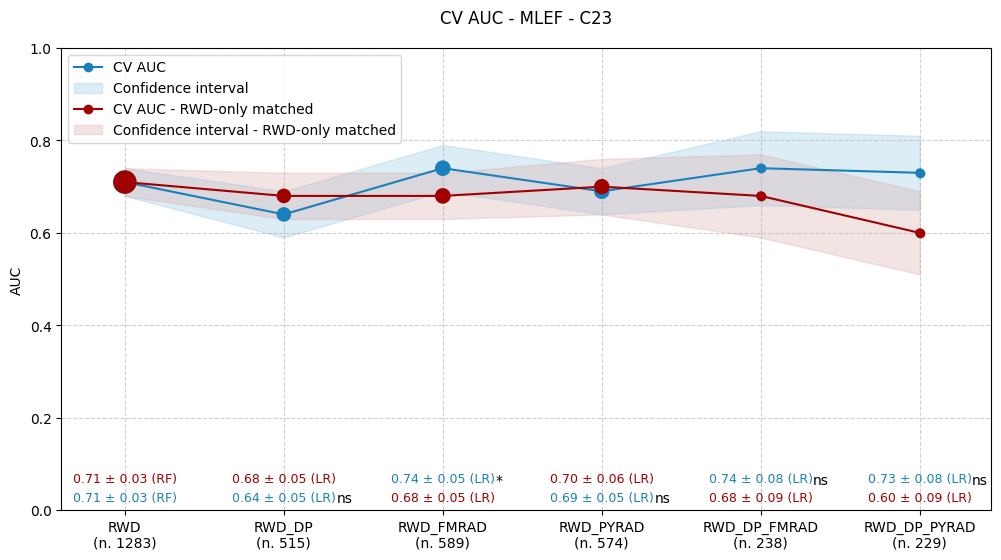

In [ ]:
plot_auc_from_folder(
    architecture="MLEF",
    outcome="OS_24",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

# BIOMARKER COMPARISON SPIDER PLOT

Thresholds used to calculate biomarkers: (biomarker >= threshold will be convert into class 1)
- PDL1: 
    - 1 for OS 6, DCR (PDL1 >= 1%); 2 for OS 24 (PDL1 >= 50%)
- NLR: 4
- LDH: 400
- ECOG: 2

Take the real values of the biomarker, remove the missing ones.
According to the outcome (DCR/OS6/OS24) the biomarker will be converted into TP, FP, TN, FN.
Then calculate AUC, accuracy, sensitivity, specificity using as y_true the outcome and y_pred the biomarker.
On the same subset of patients, for each biomarker, use the model to compute the metrics

In [2]:
rwd = pd.read_csv('data/rwd.csv')
outcome = 'OS_24' #or 'OS_6' or 'DCR'
outcomes = pd.read_csv('data/outcomes.csv')
rwd = rwd.merge(outcomes, on='Subject', how='inner')
with open('mlef_pipeline/split.json', 'r') as f:
    split = json.load(f)
test = rwd[rwd['Subject'].isin(split['TEST_SET'])]
test = test[test[outcome].notna()].reset_index(drop=True)
test
y_pred_mlef = pd.read_csv(f'mlef_pipeline/MLEF/C23/{outcome}/RWD/prediction_test.csv')

,Subject,AGE AT DIAGNOSIS,AGE AT IO START,SEX,ECOG PS,SMOKING CURRENT,SMOKING FORMER,SMOKING NEVER,EVER SMOKED,SMOKING PACKYEAR CUTOFF 10,...,IO IOCT_y,HISTOLOGY SQUAMOUS_y,ORR,DCR,CBR,PFS MONTHS,OS MONTHS,TTF MONTHS,OS_6,OS_24
0,GHD1030052,50.391781,50.583562,0,NaN,0.0,0.0,1.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,2.923784,6.701708,2.036794,1.0,0.0
1,GHD1030058,70.164384,70.254795,1,NaN,0.0,1.0,0.0,1.0,NaN,...,1,0.0,0.0,0.0,0.0,8.212878,8.212878,3.942181,1.0,0.0
2,GHD1030060,75.482192,75.531507,0,NaN,1.0,0.0,0.0,1.0,1.0,...,1,0.0,0.0,0.0,0.0,1.905388,1.905388,1.314060,0.0,0.0
3,GHD1030062,59.312329,59.679452,0,1.0,1.0,0.0,0.0,1.0,1.0,...,1,0.0,0.0,0.0,0.0,2.956636,8.344284,2.431012,1.0,0.0
4,GHD1030064,48.402740,48.487671,1,0.0,0.0,1.0,0.0,1.0,0.0,...,1,0.0,1.0,1.0,1.0,5.486202,20.926413,5.847569,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,VHIO1020160,64.205479,66.602740,1,1.0,1.0,0.0,0.0,1.0,1.0,...,0,0.0,0.0,0.0,0.0,1.018397,1.576873,0.361367,0.0,0.0
222,VHIO1020164,71.427397,71.128767,1,1.0,1.0,0.0,0.0,1.0,1.0,...,0,0.0,0.0,0.0,0.0,0.788436,0.919842,0.459921,0.0,0.0
223,VHIO1020166,52.953425,53.958904,1,1.0,1.0,0.0,0.0,1.0,1.0,...,0,1.0,0.0,0.0,0.0,1.084100,3.876478,0.886991,0.0,0.0
224,VHIO1020173,58.539726,58.846575,1,1.0,0.0,1.0,0.0,1.0,0.0,...,0,0.0,1.0,1.0,1.0,114.816032,114.816032,109.296978,1.0,1.0


In [5]:
from helpers import *

if outcome == 'OS_24':
    bio_pdl1 = 'BIO_PDL1_50'
else:
    bio_pdl1 = 'BIO_PDL1_1'

test_biomarkers, biomarkers = add_single_biomarkers(
    outcome=outcome,
    df=test,
    to_show=[bio_pdl1, 'BIO_NLR', 'BIO_LDH', 'BIO_ECOG']
)
test_biomarkers = convert_to_binary(test_biomarkers, biomarkers)
test_biomarkers[[bio_pdl1, 'binary_' + bio_pdl1, 'BIO_NLR', 'binary_BIO_NLR', 'BIO_LDH', 'binary_BIO_LDH', 'BIO_ECOG', 'binary_BIO_ECOG']]

,BIO_PDL1_50,binary_BIO_PDL1_50,BIO_NLR,binary_BIO_NLR,BIO_LDH,binary_BIO_LDH,BIO_ECOG,binary_BIO_ECOG
0,FP,1.0,TN,0.0,TN,0.0,NaN,NaN
1,FP,1.0,TN,0.0,FP,1.0,NaN,NaN
2,TN,0.0,FP,1.0,FP,1.0,NaN,NaN
3,TN,0.0,FP,1.0,FP,1.0,FP,1.0
4,TN,0.0,FP,1.0,FP,1.0,FP,1.0
...,...,...,...,...,...,...,...,...
221,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
222,TN,0.0,FP,1.0,NaN,NaN,FP,1.0
223,NaN,NaN,TN,0.0,NaN,NaN,FP,1.0
224,TP,1.0,NaN,NaN,NaN,NaN,TP,1.0


In [6]:
#compute metrics for each biomarker
results = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio.reset_index(drop=True, inplace=True)
    metrics = compute_metrics_biomarker(bio[outcome], bio[biomarker])
    metrics['n.patients'] = len(bio)
    results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


Metrics for binary_BIO_PDL1_50:
AUC: 0.5317, Accuracy: 0.6257, Sensitivity: 0.3333, Specificity: 0.7302

Metrics for binary_BIO_NLR:
AUC: 0.6560, Accuracy: 0.6700, Sensitivity: 0.6275, Specificity: 0.6846

Metrics for binary_BIO_LDH:
AUC: 0.5815, Accuracy: 0.4481, Sensitivity: 0.8837, Specificity: 0.2793

Metrics for binary_BIO_ECOG:
AUC: 0.6177, Accuracy: 0.4515, Sensitivity: 0.9821, Specificity: 0.2533



In [ ]:
#compute model metrics on biomarkers subset

mlef_model_results = {}
patients = {}
for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    bio = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing model on n. {len(bio)} patients...")
    
    y_pred_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_pred'].values
    y_proba_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_proba'].values
    y_true_bio = y_pred_mlef[y_pred_mlef['Subject'].isin(bio)]['y_true'].values

    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(bio)
    patients[biomarker] = bio.tolist()
    mlef_model_results[biomarker] = metrics
    print(f"Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")


In [ ]:

# Apply DeLong test to compare biomarkers vs ML model
delong_mlef_results = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs ML Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding test data and model predictions
    test_bio = test[test.index.isin(bio_subjects)]
    y_true_bio = test_bio[outcome].values
    
    # Biomarker predictions (binary, so we use them as probabilities)
    biomarker_preds = bio_subset.set_index('Subject').loc[test_bio.index, biomarker].values
    
    # ML model predictions (probabilities)
    ml_model_preds = y_pred_mlef[y_pred_mlef['Subject'].isin(bio_subjects)]['y_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, ml_model_preds)
    delong_mlef_results[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"ML Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than ML model")
        else:
            print("→ ML model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and ML model")

In [ ]:
delong_mlef_summary = []
for biomarker, result in delong_mlef_results.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_mlef_summary.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'ML_Model_AUC': f"{result['auc2']:.3f}",
        'ML_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'ML Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_mlef = pd.DataFrame(delong_mlef_summary)
print("\n=== DeLong Test Summary (MLEF) ===")
print(delong_mlef.to_string(index=False))


In [ ]:
biomarker_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()},
}
mlef_model_scores = {
    'PDL1': {k: round(v, 2) for k, v in mlef_model_results['binary' + bio_pdl1].items()},
    'NLR': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in mlef_model_results['binary_BIO_ECOG'].items()}
}
p_values_mlef = [float(delong_mlef[delong_mlef['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_50', 'NLR', 'LDH', 'ECOG']]
size = [
    results['binary' + bio_pdl1]['n.patients'],
    results['binary_BIO_NLR']['n.patients'],
    results['binary_BIO_LDH']['n.patients'],
    results['binary_BIO_ECOG']['n.patients']
]

In [ ]:
# Load model predictions from parquet file
from sklearn.metrics import roc_auc_score
import numpy as np

predictions_df = pd.read_parquet('dl-models/dcr/rwd_radfm_dp/predictions.parquet') #check the correct path

# Convert non-softmaxed predictions to probabilities using softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Apply softmax to get probabilities
logits = predictions_df[['y_pred0', 'y_pred1']].values
probabilities = softmax(logits)
predictions_df['y_pred_proba'] = probabilities[:, 1]  # Probability of positive class

print(f'Loaded predictions for {len(predictions_df)} patients')
print(f'AUC from loaded predictions: {roc_auc_score(predictions_df["y_true"], predictions_df["y_pred_proba"]):.4f}')



In [ ]:
# Test DLIF model predictions on biomarkers subset using loaded predictions from parquet
dl_model_results = {}
patients = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    # Get patients where biomarker is available
    bio_patients = test_biomarkers[test_biomarkers[biomarker].notna()]['Subject']
    print(f"Testing DLIF model on n. {len(bio_patients)} patients...")
    
    # Match with predictions data using slide column
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_patients)]
    
    # Get true labels and predicted probabilities
    y_true_bio = predictions_subset['y_true'].values
    y_proba_bio = predictions_subset['y_pred_proba'].values
    y_pred_bio = (y_proba_bio >= 0.5).astype(int)
    
    # Calculate metrics
    metrics = compute_metrics(y_true_bio, y_pred_bio, y_proba_bio)
    metrics['n.patients'] = len(predictions_subset)
    patients[biomarker] = bio_patients.tolist()
    dl_model_results[biomarker] = metrics
    
    print(f"DLIF Metrics for {biomarker}:")
    print(f"AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}, Sensitivity: {metrics['Sensitivity']:.4f}, Specificity: {metrics['Specificity']:.4f}\n")
 

In [ ]:

# Apply DeLong test to compare biomarkers vs DLIF model using loaded predictions
delong_results_dl = {}

for biomarker in ['binary_' + bio_pdl1, 'binary_BIO_NLR', 'binary_BIO_LDH', 'binary_BIO_ECOG']:
    print(f"\n=== DeLong Test for {biomarker} vs DLIF Model ===")
    
    # Get subset of data where biomarker is available
    bio_subset = test_biomarkers[test_biomarkers[biomarker].notna()]
    bio_subjects = bio_subset['Subject']
    
    # Get corresponding predictions data
    predictions_subset = predictions_df[predictions_df['slide'].isin(bio_subjects)]
    
    # Match biomarker data with predictions by Subject/slide
    merged_data = bio_subset.merge(predictions_subset, left_on='Subject', right_on='slide', how='inner')
    
    y_true_bio = merged_data['y_true'].values
    
    # Biomarker predictions (binary, so we use them as probabilities)  
    biomarker_preds = merged_data[biomarker].values
    
    # DLIF model predictions (probabilities)
    dl_model_preds = merged_data['y_pred_proba'].values
    
    # Perform DeLong test
    delong_result = delong_test_comparison(y_true_bio, biomarker_preds, dl_model_preds)
    delong_results_dl[biomarker] = delong_result
    
    # Print results
    print(f"Biomarker AUC: {delong_result['auc1']:.4f} (95% CI: {delong_result['auc1_ci'][0]:.4f}-{delong_result['auc1_ci'][1]:.4f})")
    print(f"DLIF Model AUC: {delong_result['auc2']:.4f} (95% CI: {delong_result['auc2_ci'][0]:.4f}-{delong_result['auc2_ci'][1]:.4f})")
    print(f"AUC Difference: {delong_result['auc_difference']:.4f}")
    print(f"Z-score: {delong_result['z_score']:.4f}")
    print(f"P-value: {delong_result['p_value']:.6f}")
    print(f"Statistically significant (p < 0.05): {'Yes' if delong_result['significant'] else 'No'}")
    
    if delong_result['significant']:
        if delong_result['auc_difference'] > 0:
            print("→ Biomarker performs significantly better than DLIF model")
        else:
            print("→ DLIF model performs significantly better than biomarker")
    else:
        print("→ No significant difference between biomarker and DLIF model")

In [ ]:
# Create a summary table of DeLong test results for DLIF model
delong_summary_dl = []
for biomarker, result in delong_results_dl.items():
    biomarker_name = biomarker.replace('binary_BIO_', '')
    
    delong_summary_dl.append({
        'Biomarker': biomarker_name,
        'Biomarker_AUC': f"{result['auc1']:.3f}",
        'Biomarker_CI': f"({result['auc1_ci'][0]:.3f}-{result['auc1_ci'][1]:.3f})",
        'DLIF_Model_AUC': f"{result['auc2']:.3f}",
        'DLIF_Model_CI': f"({result['auc2_ci'][0]:.3f}-{result['auc2_ci'][1]:.3f})",
        'AUC_Difference': f"{result['auc_difference']:.3f}",
        'P_value': f"{result['p_value']:.6f}",
        'Significant': 'Yes' if result['significant'] else 'No',
        'Better_Model': 'Biomarker' if result['auc_difference'] > 0 and result['significant'] 
                       else 'DLIF Model' if result['auc_difference'] < 0 and result['significant']
                       else 'No difference'
    })

delong_df_dl = pd.DataFrame(delong_summary_dl)
print("\n=== DeLong Test Summary (DLIF) ===")
print(delong_df_dl.to_string(index=False))

In [ ]:
# DLIF model scores 
dlif_scores = {
    'PDL1': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_PDL1_1'].items()},
    'NLR': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_NLR'].items()},
    'LDH': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_LDH'].items()},
    'ECOG': {k: round(v, 2) for k, v in dl_model_results['binary_BIO_ECOG'].items()}
}
p_values_dl = [float(delong_df_dl[delong_df_dl['Biomarker'] == biomarker]['P_value'].values[0]) for biomarker in ['PDL1_1', 'NLR', 'LDH', 'ECOG']]  # DLIF p-values

In [ ]:
biomarkers = ['PDL1', 'NLR', 'LDH', 'ECOG']

metrics = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
path = 'Biomarker_comparison'
plot_radar_charts(
    biomarker_scores=biomarker_scores,
    model_scores=mlef_model_scores,
    dl_scores=dlif_scores,
    p_values_ml=p_values_mlef,
    p_values_dl=p_values_dl,
    size=size,
    biomarkers=biomarkers,
    metrics=metrics,
    title_prefix=f'{outcome} Model',
    path=path
)


# FARINESS RESULTS PLOT